# GFS model output

The Global Forecast System is NOAA's global weather model, run four times a
day at 00, 06, 12, and 18 UTC. NCEP publishes its GRIB2 output to the
anonymous `noaa-gfs-bdp-pds` bucket on AWS, and one file holds one run at one
forecast hour on one grid: several hundred fields covering the whole globe.

This walkthrough pulls the 00 UTC analysis of 6 May 2024 on the 1 degree grid,
lists what the file holds, reads surface CAPE, 0–3 km storm-relative
helicity, and the land mask, and maps where the atmosphere was unstable that
hour. It needs `usdata[grib]` and matplotlib; the download is 42 MB and the
run takes a few seconds.

In [1]:
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; xarray {xr.__version__}; numpy {np.__version__}")

Executed (UTC): 2026-09-25T15:35:58+00:00
usdata 0.27.0; xarray 2026.7.0; numpy 2.5.2


## Select

The manifest names one run, one hour, and one grid. The window selects runs by
initialization time, so 00:00 to 00:00 UTC with `cycle: 0` is exactly the run
started at midnight UTC on 6 May 2024. `forecast_hour: 0` is that run's
analysis, the model's estimate of the atmosphere at initialization rather
than a forecast. `resolution: 1p00` picks the 1 degree grid, about 42 MB; the
default 0.25 degree grid carries the same fields in about 508 MB.

`noaa:gfs` subsets in time only, so this query downloads the whole file.
Naming GRIB2 messages with the `messages` parameter would fetch byte ranges of
it instead; the
[GFS guide](https://docs.usdata.dev/providers/noaa-gfs/#fetching-selected-messages)
lists the selectors.

In [2]:
print(manifest.read_text())

name: oklahoma-gfs-analysis
sources:
  - dataset: noaa:gfs
    start: 2024-05-06T00:00:00Z
    end: 2024-05-06T00:00:00Z
    params:
      cycle: 0
      forecast_hour: 0
      resolution: 1p00



## What arrives

One GRIB2 object from S3. The lockfile beside the manifest pins its name and
SHA-256, so a pull with the lockfile present restores exactly these bytes.

In [3]:
result = pull(manifest)
(item,) = result.fetched
print("File:", item.path.name)
print(f"Bytes: {item.provenance.size} ({item.provenance.size / 1e6:.1f} MB)")
print("Source:", item.provenance.source_url)
print("Retrieved (UTC):", item.provenance.retrieved_at.isoformat(timespec="seconds"))
print("Checksum:", item.provenance.checksum)
print("Valid time:", item.asset.time.start.isoformat())

File: gfs.20240506.t00z.pgrb2.1p00.f000
Bytes: 42362644 (42.4 MB)
Source: s3://noaa-gfs-bdp-pds/gfs.20240506/00/atmos/gfs.t00z.pgrb2.1p00.f000
Retrieved (UTC): 2026-09-25T15:36:02+00:00
Checksum: sha256:63817e7acae0e1b5dd85cef3b4ffa8b03aba3d7707fdaa9cd54e2dcb5500643e
Valid time: 2024-05-06T00:00:00+00:00


## Open

A GRIB2 file is a stack of independent messages, one per field and level.
`item.inspect()` lists them without decoding any values. Most of this file is
upper-air fields on pressure levels; the handful of surface and layer fields
below are the ones severe-weather work starts from.

In [4]:
messages = pd.DataFrame(
    message.model_dump(include={"short_name", "type_of_level", "level", "units"})
    for message in item.inspect().grib2.messages
)
print(len(messages), "messages")
print(messages["type_of_level"].value_counts().head(4).to_string())
messages[messages["short_name"].isin(["cape", "hlcy", "lsm"])]

696 messages
type_of_level
isobaricInhPa        462
isobaricInPa          80
surface               31
heightAboveGround     25


,short_name,type_of_level,level,units
601,cape,surface,0,J kg**-1
612,hlcy,heightAboveGroundLayer,3000,m**2 s**-2
663,cape,pressureFromGroundLayer,18000,J kg**-1
676,cape,pressureFromGroundLayer,9000,J kg**-1
678,cape,pressureFromGroundLayer,25500,J kg**-1
681,lsm,surface,0,(0 - 1)


`open_grib2(select=...)` decodes the messages that match every key. Surface CAPE and
the land mask share one level type and one level, so each variable keeps its
bare short name. Helicity is selected on its own with its level, since GFS
publishes only the 0–3 km layer.

The grid is regular: `latitude` runs from 90 to −90 and `longitude` from 0 to
359 degrees east, both one-dimensional. Time is in each variable's
attributes, where `valid_time` is the initialization plus the forecast hour.

In [5]:
surface = item.open_grib2(select={"shortName": ["cape", "lsm"], "typeOfLevel": "surface"})
helicity = item.open_grib2(
    select={"shortName": "hlcy", "typeOfLevel": "heightAboveGroundLayer", "level": 3000}
)
fields = xr.merge([surface, helicity], compat="override")
pd.DataFrame(
    {
        "variable": name,
        "long_name": variable.attrs["name"],
        "units": variable.attrs["units"],
        "valid_time": variable.attrs["valid_time"],
        "dims": str(variable.dims),
    }
    for name, variable in fields.data_vars.items()
)

,variable,long_name,units,valid_time,dims
0,cape,Convective available potential energy,J kg**-1,2024-05-06T00:00:00+00:00,"('latitude', 'longitude')"
1,lsm,Land-sea mask,(0 - 1),2024-05-06T00:00:00+00:00,"('latitude', 'longitude')"
2,hlcy,Storm relative helicity,m**2 s**-2,2024-05-06T00:00:00+00:00,"('latitude', 'longitude')"


On a regular grid the nearest point is the nearest latitude and the nearest
longitude, found separately, once a western longitude is written in the 0 to
360 convention.

In [6]:
place_lat, place_lon = 35.47, -97.52  # Oklahoma City
y = int(np.abs(fields.latitude.values - place_lat).argmin())
x = int(np.abs(fields.longitude.values - place_lon % 360).argmin())
point = fields.isel(latitude=y, longitude=x)
print(f"Nearest grid point: {float(point.latitude):.1f} N {float(point.longitude) - 360:.1f} E")
print(f"Surface CAPE there: {float(point['cape']):.0f} J/kg")
print(f"0-3 km helicity there: {float(point['hlcy']):.0f} m2/s2")

Nearest grid point: 35.0 N -98.0 E
Surface CAPE there: 61 J/kg
0-3 km helicity there: 136 m2/s2


## A first look

Surface CAPE is the energy available to a rising parcel, the fuel for
thunderstorms. The map shades it over the whole globe, with longitudes moved
to −180 to 180 so the Americas sit on the left, and coastlines drawn from the
file's own land mask.

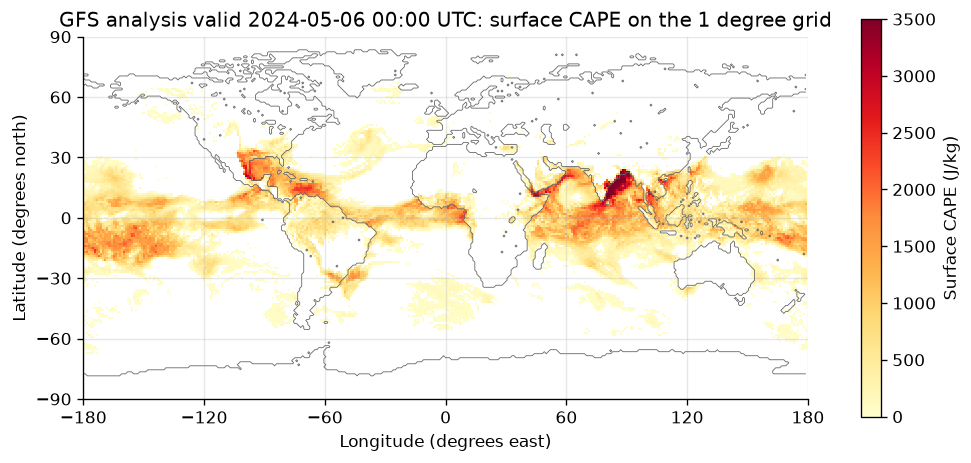

In [7]:
world = fields.assign_coords(longitude=(fields.longitude + 180) % 360 - 180).sortby("longitude")

fig, ax = plt.subplots(layout="constrained")
shaded = ax.pcolormesh(
    world.longitude,
    world.latitude,
    world["cape"].where(world["cape"] >= 50),
    cmap="YlOrRd",
    vmin=0,
    vmax=3500,
    shading="nearest",
)
ax.contour(
    world.longitude, world.latitude, world["lsm"], levels=[0.5], colors="0.4", linewidths=0.5
)
ax.set_aspect("equal")
ax.set(
    xlim=(-180, 180),
    ylim=(-90, 90),
    xticks=range(-180, 181, 60),
    yticks=range(-90, 91, 30),
    title="GFS analysis valid 2024-05-06 00:00 UTC: surface CAPE on the 1 degree grid",
    xlabel="Longitude (degrees east)",
    ylabel="Latitude (degrees north)",
)
fig.colorbar(shaded, ax=ax, label="Surface CAPE (J/kg)", shrink=0.75)
plt.show()

In [8]:
cape = world["cape"]
peak = cape.where(cape == cape.max(), drop=True)
print(f"Largest surface CAPE: {float(cape.max()):.0f} J/kg")
print(f"  at {float(peak.latitude[0]):.0f} N {float(peak.longitude[0]):.0f} E")
unstable = cape >= 1000
tropical = unstable.where(np.abs(world.latitude) < 30, False)
print(f"Grid cells with CAPE >= 1000 J/kg: {int(unstable.sum())}")
print(f"  within 30 degrees of the equator: {int(tropical.sum())}")

Largest surface CAPE: 4096 J/kg
  at 12 N 80 E
Grid cells with CAPE >= 1000 J/kg: 3653
  within 30 degrees of the equator: 3576


At this hour nearly all the instability on Earth sat in the tropics: 3576 of
the 3653 cells with at least 1000 J/kg lie within 30 degrees of the equator,
and the largest value is over the Bay of Bengal, off the southeast coast of
India. The two tongues reaching past 30 degrees are over Texas and the Gulf
coast, and over southern Brazil. Cells under 50 J/kg are left blank.

Oklahoma City's cell, a 1 degree box about 100 km across, held 61 J/kg at
7 pm local time on 5 May. The analysis is 28 hours 39 minutes before the
Oklahoma County tornado report that the
[severe-weather case study](https://usdata.dev/studies/severe-weather-case-study/)
follows, so it describes the air mass a day earlier, not the environment the
storms formed in; the [HRRR walkthrough](https://usdata.dev/datasets/noaa/hrrr/)
maps the same two fields on a 3 km grid at 20 UTC on 6 May.

## Pin and cite

`verify` checks the cached file against the lockfile's checksum. Keep the
manifest, lockfile, and cached bytes together; public cloud retention is not
a promise.

In [9]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())

noaa:gfs
  NOAA Global Forecast System (GFS) was accessed on 2026-09-16 from https://registry.opendata.aws/noaa-gfs-bdp-pds
  homepage: https://registry.opendata.aws/noaa-gfs-bdp-pds/
  license: US Government Work (public domain)
  terms: https://www.noaa.gov/information-technology/open-data-dissemination
  retrieved: 2026-09-16; 1 checksummed asset (42,362,644 bytes) pinned by usdata 0.18.0
  sources: 1


## What was awkward

- Pressure levels come under two level types. Levels from 1000 to 1 hPa are
  `isobaricInhPa`, but the eight above them, 0.7 to 0.01 hPa, are
  `isobaricInPa` with levels numbered in pascals, so a select for every
  temperature level with `typeOfLevel: isobaricInhPa` misses eight of them,
  and 80 messages in all, without saying so.
- Two opens and an `xr.merge` were the simplest way to get CAPE and helicity
  with short names; one `select` spanning both level types would rename every
  variable to `shortName_typeOfLevel_level`.
- Units arrive as raw ecCodes strings, `J kg**-1` and `m**2 s**-2`. Every plot
  label and sentence translates them by hand.
- Longitudes run 0 to 359, so a western place needs `% 360` to be found and
  a map of the Americas needs the coordinates rolled and re-sorted first.
- The two dates in this notebook disagree. A pull that restores from the
  committed lockfile downloads the object again, so `retrieved_at` above is
  the day this notebook ran, while the citation says the file was accessed on
  the day the lockfile was first written. The citation is the one to quote,
  but nothing on the fetched item says so.
- The `grib` extra installs with pip alone on Linux, and on Windows through
  Python 3.13; macOS needs the ecCodes library from conda-forge or Homebrew
  first. The [reader reference](https://docs.usdata.dev/reference/readers/)
  has the details.